# **Exploratory Data Anaylsis**

## **Overview**

This file consists of ***Visuals***  from the *IMDB Top 10000 Movies* Cleanded Earlier 

## **Objective**

To Present Insights and Relations between Values in Dataset Visually.

## **Key Insights from Dataset**

- Top 10 Grossing Movies
- No of Votes Vs IMDb Rating 
- Star vs Gross

## **Libraries and Loading Data**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

Visual = pd.read_excel('C:/Users/Dell/Downloads/Final Cleaned Dataset.xlsx')

## **Reading Dataset**

In [5]:
Visual.head(5)

,Movie Title,Release Year,Genres,IMDb Rating,Director,Actor 1,Actor 2,User Votes,Box Office Collections
0,The Shawshank Redemption,1994,Drama,9.3,Frank Darabont,Tim Robbins,Morgan Freeman,2343110,28341469.0
1,The Godfather,1972,"Crime, Drama",9.2,Francis Ford Coppola,Marlon Brando,Al Pacino,1620367,134966411.0
2,The Dark Knight,2008,"Action, Crime, Drama",9.0,Christopher Nolan,Christian Bale,Heath Ledger,2303232,534858444.0
3,The Godfather: Part II,1974,"Crime, Drama",9.0,Francis Ford Coppola,Al Pacino,Robert De Niro,1129952,57300000.0
4,12 Angry Men,1957,"Crime, Drama",9.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,689845,4360000.0


## **Understanding the Sturcture of Data**

In [6]:
Visual.shape

(1000, 9)

In [7]:
Visual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Movie Title             1000 non-null   object 
 1   Release Year            1000 non-null   int64  
 2   Genres                  1000 non-null   object 
 3   IMDb Rating             1000 non-null   float64
 4   Director                1000 non-null   object 
 5   Actor 1                 1000 non-null   object 
 6   Actor 2                 1000 non-null   object 
 7   User Votes              1000 non-null   int64  
 8   Box Office Collections  1000 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 70.4+ KB


In [8]:
Visual.describe()

,Release Year,IMDb Rating,User Votes,Box Office Collections
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,1991.270000,7.948800,2.736368e+05,6.076811e+07
std,23.223316,0.275744,3.274299e+05,1.014023e+08
min,1920.000000,7.600000,2.508800e+04,1.305000e+03
25%,1976.000000,7.700000,5.534425e+04,5.016434e+06
50%,1999.000000,7.900000,1.381685e+05,2.364363e+07
75%,2009.000000,8.100000,3.741612e+05,6.166243e+07
max,2020.000000,9.300000,2.343110e+06,9.366622e+08


In [9]:
Visual.describe(include='object')

,Movie Title,Genres,Director,Actor 1,Actor 2
count,1000,1000,1000,1000,1000
unique,996,201,547,660,838
top,Fiddler on the Roof,Drama,Alfred Hitchcock,Tom Hanks,Emma Watson
freq,2,85,14,12,7


In [10]:
Visual.isnull().sum()

Movie Title               0
Release Year              0
Genres                    0
IMDb Rating               0
Director                  0
Actor 1                   0
Actor 2                   0
User Votes                0
Box Office Collections    0
dtype: int64

In [11]:
Visual.nunique()

Movie Title               996
Release Year               99
Genres                    201
IMDb Rating                17
Director                  547
Actor 1                   660
Actor 2                   838
User Votes                996
Box Office Collections    826
dtype: int64

**Convert Release Year to Int for Smooth Operations if needed**

In [12]:
Visual['Release Year'].unique()

array([1994, 1972, 2008, 1974, 1957, 2003, 1993, 2010, 1999, 2001, 1966,
       2002, 1990, 1980, 1975, 2020, 2019, 2014, 1998, 1997, 1995, 1991,
       1977, 1962, 1954, 1946, 2011, 2006, 2000, 1988, 1985, 1968, 1960,
       1942, 1936, 1931, 2018, 2017, 2016, 2012, 2009, 2007, 1984, 1981,
       1979, 1971, 1963, 1964, 1950, 1940, 2013, 2005, 2004, 1992, 1987,
       1986, 1983, 1976, 1973, 1965, 1959, 1958, 1952, 1948, 1944, 1941,
       1927, 1921, 2015, 1996, 1989, 1978, 1961, 1955, 1953, 1925, 1924,
       1982, 1967, 1951, 1949, 1939, 1937, 1934, 1928, 1926, 1920, 1970,
       1969, 1956, 1947, 1945, 1930, 1938, 1935, 1933, 1932, 1922, 1943])

In [13]:
nan_rows=Visual[Visual['Release Year'].isna()]
print(nan_rows)

Empty DataFrame
Columns: [Movie Title, Release Year, Genres, IMDb Rating, Director, Actor 1, Actor 2, User Votes, Box Office Collections]
Index: []


In [14]:
Visual['Release Year'] = pd.to_numeric(Visual['Release Year'], errors='coerce')

In [15]:
Visual['Release Year'] = Visual['Release Year'].astype(int)
Visual['Release Year'].dtype

dtype('int64')

## **Top 10 Movies Upto 2020** 
Note - *Its their Domestic Collection and Not World Wide Collections*  
- Refer to this Link for Proof: https://www.boxofficemojo.com/chart/top_lifetime_gross/ 

In [16]:
print(Visual.columns)

Index(['Movie Title', 'Release Year', 'Genres', 'IMDb Rating', 'Director',
       'Actor 1', 'Actor 2', 'User Votes', 'Box Office Collections'],
      dtype='object')


In [17]:
sb.set(style="whitegrid")

C:\Users\Dell\AppData\Local\Temp\ipykernel_8572\2920590279.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Box Office Collections', y='Movie Title', data=Top_10, palette=vlag_colors)


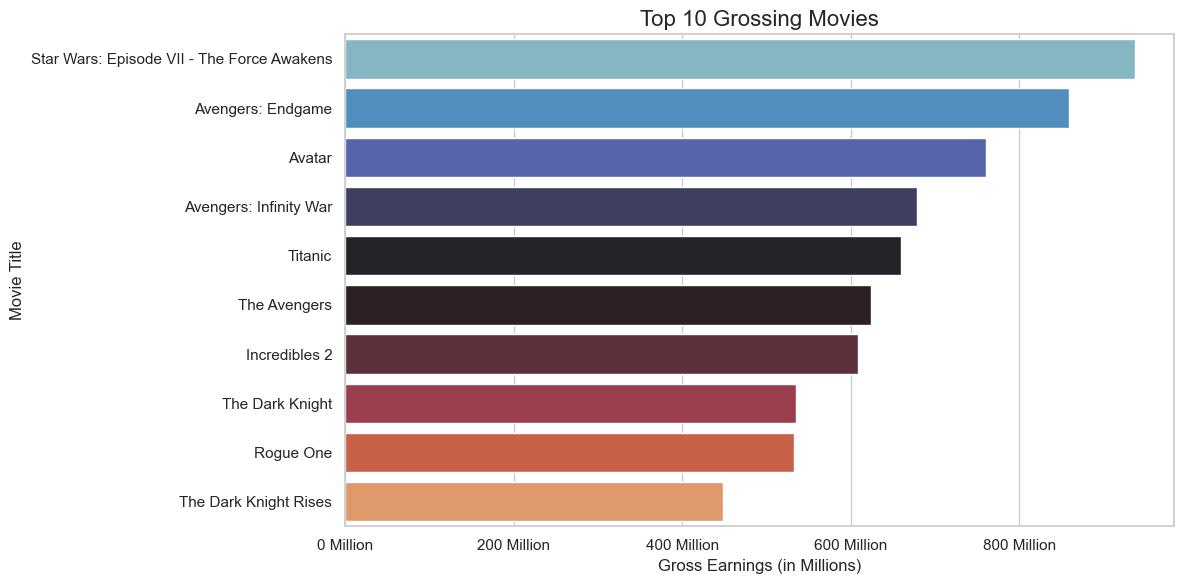

In [ ]:
import matplotlib.ticker as mtick

Top_10 = Visual.nlargest(10, 'Box Office Collections')

plt.figure(figsize=(12, 6))
vlag_colors = sb.color_palette("icefire", n_colors=10)
sb.barplot(x='Box Office Collections', y='Movie Title', data=Top_10, palette=vlag_colors)
plt.title('Top 10 Grossing Movies', fontsize=16,loc='center')
plt.xlabel('Gross Earnings (in Millions)',loc='center')
plt.ylabel('Movie Title', loc='center')
fmt = lambda x, _: f'{int(x/1e6)} Million'
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(fmt))
plt.tight_layout()
plt.show()

This bar plot displays the Top 10 movies based on their total Box Office Collections.
Each bar represents a movie, and its height corresponds to its total earnings.
This graph provides a clear comparison of which movies have performed best commercially.
The bars are sorted in descending order, making it easy to identify the highest grossing movie at a glance.  
This bar plot displays the top 10 actors based on their combined box office collections from roles as both lead and co-star. The graph highlights which actors consistently feature in commercially successful films. We observe that a few actors dominate in terms of cumulative gross — indicating their bankability and frequent appearances in hit movies. This plot helps pinpoint top-performing stars in the dataset.


# **No of Votes VS IMDb Ratings and Impact on Collections**

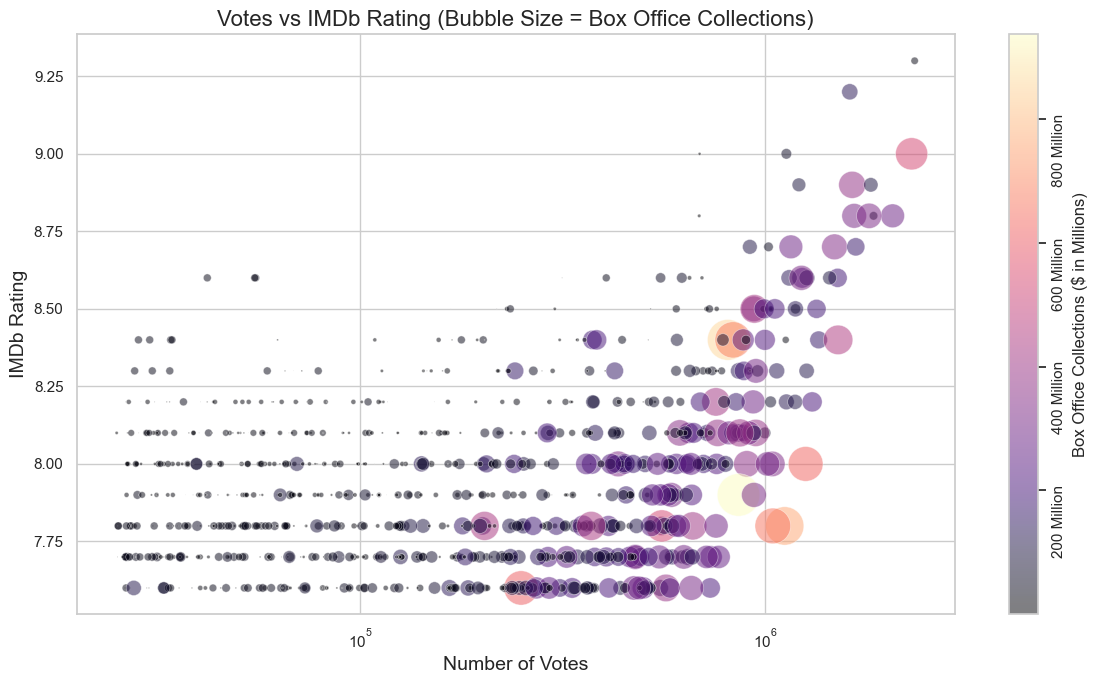

In [39]:
plt.figure(figsize=(12, 7))

# Scatter where bubble size is based on 'Box Office Collections'
scatter=plt.scatter(Visual['User Votes'], Visual['IMDb Rating'], 
            s=Visual['Box Office Collections']/1e6,  # Scale down Box Office Collections for reasonable bubble size
            alpha=0.5, 
            c=Visual['Box Office Collections'], cmap='magma', edgecolors='w',linewidths=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Box Office Collections ($ in Millions)')

# Format the colorbar tick labels to show in Millions
cbar.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1e6)} Million'))
for t in cbar.ax.get_yticklabels():
    t.set_rotation(90)

plt.xlabel('Number of Votes', fontsize=14)
plt.ylabel('IMDb Rating', fontsize=14)
plt.title('Votes vs IMDb Rating (Bubble Size = Box Office Collections)', fontsize=16)
plt.grid(True)
plt.xscale('log')  # Optional: exponential scale for better visualization
plt.tight_layout()
plt.show()


This Bubble Plot visualizes the relationship between a movie's popularity (votes), quality (IMDb rating), and commercial success (box office collections). Most movies cluster in the 7.7–8.5 rating range with votes below 1M. The largest and brightest bubbles (high-grossing hits) correspond to movies with both high votes and high ratings — indicating that critically acclaimed and widely viewed movies also tend to perform strongly at the box office. The size and color intensity of bubbles make it easy to spot blockbuster hits at a glance.

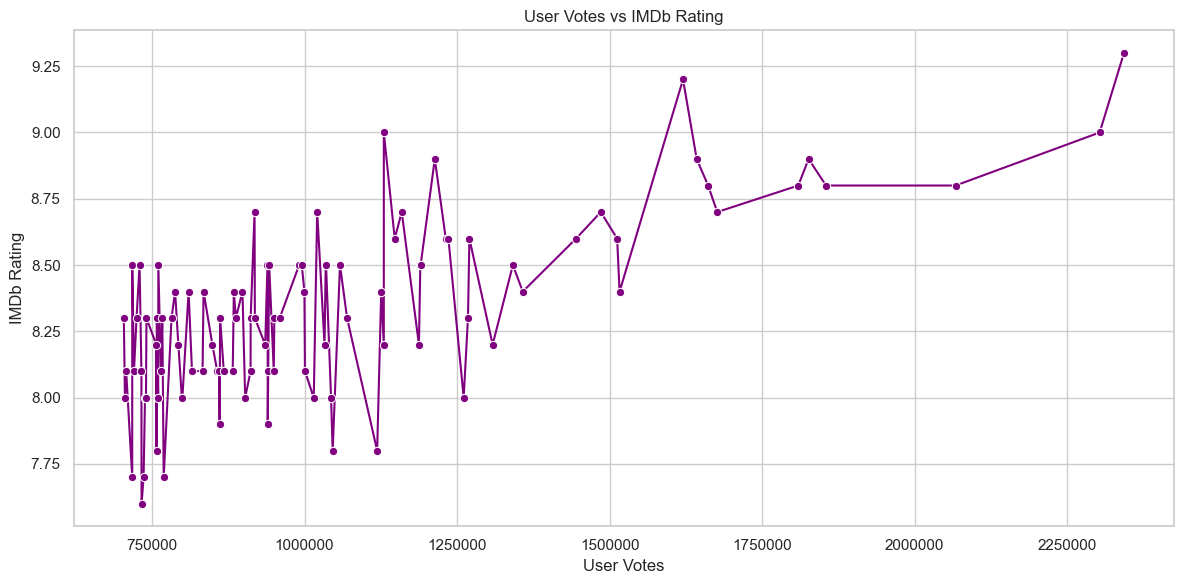

In [ ]:
sorted_df = Visual.sort_values(by='User Votes')
filtered_df = sorted_df[sorted_df['User Votes'] > 700000]
plt.figure(figsize=(12,6))
sb.lineplot(data=filtered_df, x='User Votes', y='IMDb Rating', color='purple', marker='o')
plt.title('User Votes vs IMDb Rating')
plt.xlabel('User Votes')
plt.ylabel('IMDb Rating')
plt.grid(True)

# Format X-axis (remove scientific notation)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

This line plot represents the relationship between the number of user votes and IMDb ratings for various movies. The graph reveals a generally positive trend, indicating that movies with higher vote counts tend to have higher IMDb ratings. In the initial portion of the graph, where movies have received fewer votes (mostly under one million), the ratings fluctuate more heavily, showing inconsistency in how these films were received by audiences.    As the number of votes increases, the ratings gradually stabilize and begin to climb. In the higher range of user votes (between 1 million to over 2 million), the IMDb ratings often remain above 8.5, reflecting stronger audience approval.   The plot concludes with one of the most highly rated movies, with a rating above 9.25, which also has the highest number of votes, highlighting how mass audience engagement often correlates with critical appreciation.

# **Actors Vs Gross**

In [21]:
# Combine both actor columns into one long list
actor1 = Visual[['Actor 1', 'Box Office Collections']].rename(columns={'Actor 1': 'Actor'})
actor2 = Visual[['Actor 2', 'Box Office Collections']].rename(columns={'Actor 2': 'Actor'})

# Stack them vertically
combined_actors = pd.concat([actor1, actor2])

# Group by Actor and sum their total Box Office Collections
actor_gross = combined_actors.groupby('Actor')['Box Office Collections'].sum().reset_index()


C:\Users\Dell\AppData\Local\Temp\ipykernel_8572\1463506347.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Actor', y='Box Office Collections', data=top_actors, palette='magma')


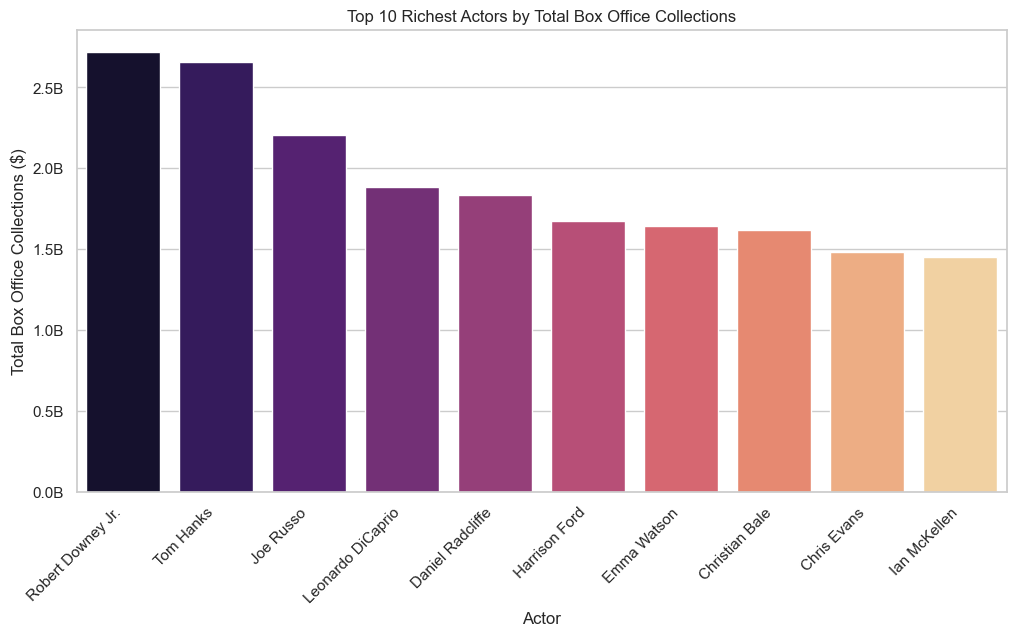

In [22]:
top_actors = actor_gross.nlargest(10, 'Box Office Collections')

plt.figure(figsize=(12,6))
sb.barplot(x='Actor', y='Box Office Collections', data=top_actors, palette='magma')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e9:.1f}B'))
plt.title('Top 10 Richest Actors by Total Box Office Collections')
plt.ylabel('Total Box Office Collections ($)')
plt.xlabel('Actor')
plt.show()

This bar plot displays the top 10 actors based on their combined box office collections from roles as both lead and co-star. The graph highlights which actors consistently feature in commercially successful films. We observe that a few actors dominate in terms of cumulative gross — indicating their bankability and frequent appearances in hit movies. This plot helps pinpoint top-performing stars in the dataset.

# **Which Actor prefer which Genre more?**

In [23]:
actor1 = Visual[['Actor 1', 'Genres']].rename(columns={'Actor 1': 'Actor'})
actor2 = Visual[['Actor 2', 'Genres']].rename(columns={'Actor 2': 'Actor'})
combined_actor_genre = pd.concat([actor1, actor2])

# Count how many times each Actor appeared in each Genre
actor_genre_counts = combined_actor_genre.groupby(['Actor','Genres']).size().reset_index(name='Count')

# For each Actor, get Genre with max Count
preferred_genre = actor_genre_counts.loc[actor_genre_counts.groupby('Actor')['Count'].idxmax()].reset_index(drop=True)

preferred_genre.sort_values(by='Count', ascending=False).head(10)  # Top 10

,Actor,Genres,Count
262,Daniel Radcliffe,"Adventure, Family, Fantasy",4
17,Al Pacino,"Biography, Crime, Drama",4
1034,Robert De Niro,"Crime, Drama",4
328,Edward Norton,Drama,3
462,Harrison Ford,"Action, Adventure, Fantasy",3
338,Elijah Wood,"Action, Adventure, Drama",3
367,Ethan Coen,"Crime, Drama, Thriller",3
368,Ethan Hawke,"Drama, Romance",3
314,Dustin Hoffman,Drama,3
357,Emma Watson,"Adventure, Family, Fantasy",3


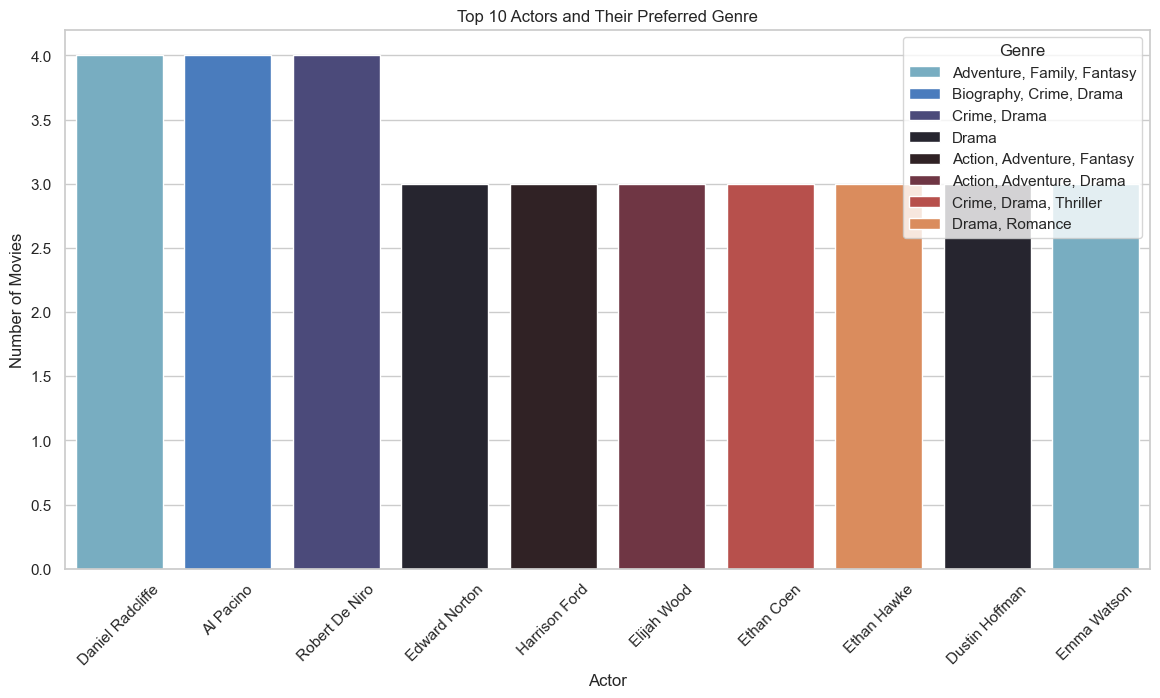

In [24]:
plt.figure(figsize=(14, 7))
top_actors = preferred_genre.sort_values('Count', ascending=False).head(10)

sb.barplot(data=top_actors, x='Actor', y='Count', hue='Genres', palette='icefire')
plt.title('Top 10 Actors and Their Preferred Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.legend(title='Genre')
plt.show()

This bar plot shows which genres are most frequently associated with each top actor. By counting the number of movies per genre for each actor, the plot highlights genre preferences and tendencies. For example, some actors may feature predominantly in Action or Drama, indicating their specialization or typecasting. This graph helps understand actor–genre alignment and can guide casting or marketing strategies.

# **Which Actor get Top IMDb Rating Maximum No of Time**

In [25]:
# Combine Actor1 and Actor2 columns together
actor1 = Visual[['Actor 1', 'IMDb Rating']].rename(columns={'Actor 1': 'Actor'})
actor2 = Visual[['Actor 2', 'IMDb Rating']].rename(columns={'Actor 2': 'Actor'})
combined_actor_rating = pd.concat([actor1, actor2])

# Group by Actor → Calculate Average IMDb
actor_avg_imdb = combined_actor_rating.groupby('Actor')['IMDb Rating'].mean().reset_index()

# Top 10 actors with highest IMDb
top_actors_imdb = actor_avg_imdb.sort_values(by='IMDb Rating', ascending=False).head(10)

C:\Users\Dell\AppData\Local\Temp\ipykernel_8572\4038552203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=top_actors_imdb, y='Actor', x='IMDb Rating', palette='rocket')


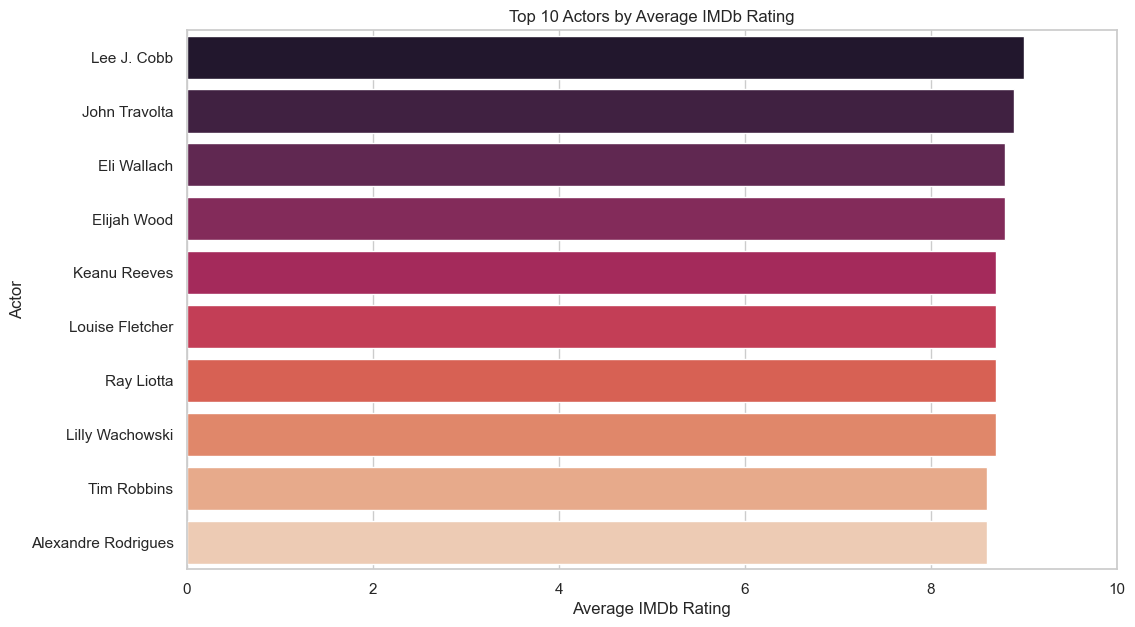

In [26]:
plt.figure(figsize=(12, 7))

sb.barplot(data=top_actors_imdb, y='Actor', x='IMDb Rating', palette='rocket')
plt.title('Top 10 Actors by Average IMDb Rating')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Actor')
plt.xlim(0, 10)  # IMDb scale is 0 to 10
plt.show()

This bar plot displays the number of times each top actor appeared in movies with top IMDb ratings (for example, movies with rating > 8.0 or top decile). It shows which actors consistently deliver high-rated films, not just based on gross but based on critical acclaim. Actors with taller bars have a strong track record of starring in quality films appreciated by audiences and critics alike